# Practice questions completion guideline:

Students are expected to work collaboratively in groups, with each team taking shared responsibility for ensuring that every member completes the assigned practice questions. Teams should actively discuss the material, clarify doubts, and support one another so that everyone fully understands the concepts. Meaningful participation and peer learning are essential. The grading will be divided equally: 50% based on individual performance and 50% based on teamwork and overall group contribution. Before submitting the notebook, each student must clearly write his or her name along with the names of all team members. After completing the practice question, upload the notebook in the moodle for class_exercise_5

##### Name:
##### Group members:

# MLP on Iris & Wine in PyTorch and TensorFlow (with guided Wine exercises)

**Goal:** Train a Multi-Layer Perceptron (MLP) on the **Iris** dataset in **PyTorch** and **TensorFlow/Keras**, then **repeat each step as an exercise on the Wine dataset**.

You will:
- Build a baseline MLP
- Train and evaluate it
- Visualize learning curves (loss/accuracy vs epoch)
- Experiment with:
  - epochs
  - learning rate
  - loss functions
  - activation functions
  - number of layers / hidden units

> **Student routine:** after each Iris experiment, you’ll see a **Wine exercise** asking you to implement the same change for Wine.


## 0) Setup
- We use `sklearn.datasets` only to **load** Iris and Wine quickly.
- We standardize features (important for MLPs on tabular data).
- We use a fixed random seed for reproducibility.

If you get an import error for `torch` or `tensorflow`, install them in your environment and rerun.


In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
np.random.seed(SEED)

def set_all_seeds(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except Exception:
        pass
    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except Exception:
        pass

set_all_seeds(SEED)

def standardize_train_test(X_train, X_test):
    mu = X_train.mean(axis=0, keepdims=True)
    sigma = X_train.std(axis=0, keepdims=True) + 1e-8
    return (X_train - mu)/sigma, (X_test - mu)/sigma, mu, sigma


## 1) Load Iris & Wine
We split into train/val/test and standardize.


In [26]:
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split

def load_dataset(name="iris", test_size=0.2, val_size=0.2, seed=42):
    if name.lower() == "iris":
        data = load_iris()
    elif name.lower() == "wine":
        data = load_wine()
    else:
        raise ValueError("name must be 'iris' or 'wine'")
    X = data["data"].astype(np.float32)
    y = data["target"].astype(np.int64)
    class_names = list(data["target_names"]) if "target_names" in data else None

    # First split off test
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=test_size, random_state=seed, stratify=y
    )
    # Then split train/val
    val_frac_of_trainval = val_size / (1.0 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=val_frac_of_trainval, random_state=seed, stratify=y_trainval
    )

    # Standardize based on TRAIN only
    X_train_s, X_val_s, mu, sigma = standardize_train_test(X_train, X_val)
    X_train_s, X_test_s, _, _ = standardize_train_test(X_train, X_test)

    return (X_train_s, y_train), (X_val_s, y_val), (X_test_s, y_test), class_names, data

iris = load_dataset("iris", seed=SEED)
wine = load_dataset("wine", seed=SEED)

for name, ds in [("Iris", iris), ("Wine", wine)]:
    (Xtr, ytr), (Xva, yva), (Xte, yte), class_names, _ = ds
    print(f"{name}: X_train {Xtr.shape}, X_val {Xva.shape}, X_test {Xte.shape}, classes={len(np.unique(ytr))}")


Iris: X_train (90, 4), X_val (30, 4), X_test (30, 4), classes=3
Wine: X_train (106, 13), X_val (36, 13), X_test (36, 13), classes=3


## Helper: plot learning curves


In [27]:
def plot_history(history, title="Training curves"):
    epochs = np.arange(1, len(history["train_loss"])+1)
    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " (Loss)")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " (Accuracy)")
    plt.legend()
    plt.show()


---

# Part A — PyTorch

## 2) Baseline MLP in PyTorch (Iris)
We build:
- Linear → Activation → Linear → Activation → Linear
- Use **CrossEntropyLoss** (includes softmax internally)


In [28]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch device:", device)

def make_torch_loaders(dataset, batch_size=32):
    (Xtr, ytr), (Xva, yva), (Xte, yte), _, _ = dataset
    Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
    ytr_t = torch.tensor(ytr, dtype=torch.long)
    Xva_t = torch.tensor(Xva, dtype=torch.float32)
    yva_t = torch.tensor(yva, dtype=torch.long)
    Xte_t = torch.tensor(Xte, dtype=torch.float32)
    yte_t = torch.tensor(yte, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(Xva_t, yva_t), batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(TensorDataset(Xte_t, yte_t), batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader, Xtr.shape[1], int(np.max(ytr)+1)

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim, activation="relu", dropout=0.0):
        super().__init__()
        acts = {
            "relu": nn.ReLU,
            "tanh": nn.Tanh,
            "sigmoid": nn.Sigmoid,
            "gelu": nn.GELU,
        }
        if activation not in acts:
            raise ValueError("activation must be one of: " + ", ".join(acts.keys()))
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(acts[activation]())
            if dropout and dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

def train_torch(model, train_loader, val_loader, epochs=100, lr=1e-2, loss_name="ce"):
    model = model.to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)  # keep SGD to match "from scratch" intuition
    if loss_name == "ce":
        criterion = nn.CrossEntropyLoss()
    elif loss_name == "mse_onehot":
        criterion = nn.MSELoss()
    else:
        raise ValueError("loss_name must be 'ce' or 'mse_onehot'")

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(1, epochs+1):
        model.train()
        train_losses, train_accs = [], []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)

            if loss_name == "ce":
                loss = criterion(logits, yb)
            else:
                # MSE on one-hot labels (usually worse for classification, but useful to demonstrate!)
                y_onehot = torch.zeros((yb.shape[0], logits.shape[1]), device=device)
                y_onehot.scatter_(1, yb.view(-1,1), 1.0)
                probs = torch.softmax(logits, dim=1)
                loss = criterion(probs, y_onehot)

            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            train_accs.append(accuracy_from_logits(logits.detach(), yb))

        model.eval()
        with torch.no_grad():
            val_losses, val_accs = [], []
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                if loss_name == "ce":
                    loss = criterion(logits, yb)
                else:
                    y_onehot = torch.zeros((yb.shape[0], logits.shape[1]), device=device)
                    y_onehot.scatter_(1, yb.view(-1,1), 1.0)
                    probs = torch.softmax(logits, dim=1)
                    loss = criterion(probs, y_onehot)
                val_losses.append(loss.item())
                val_accs.append(accuracy_from_logits(logits, yb))

        history["train_loss"].append(float(np.mean(train_losses)))
        history["val_loss"].append(float(np.mean(val_losses)))
        history["train_acc"].append(float(np.mean(train_accs)))
        history["val_acc"].append(float(np.mean(val_accs)))

    return history

def eval_torch(model, test_loader):
    model.eval()
    accs = []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            accs.append(accuracy_from_logits(logits, yb))
    return float(np.mean(accs))


PyTorch device: cpu


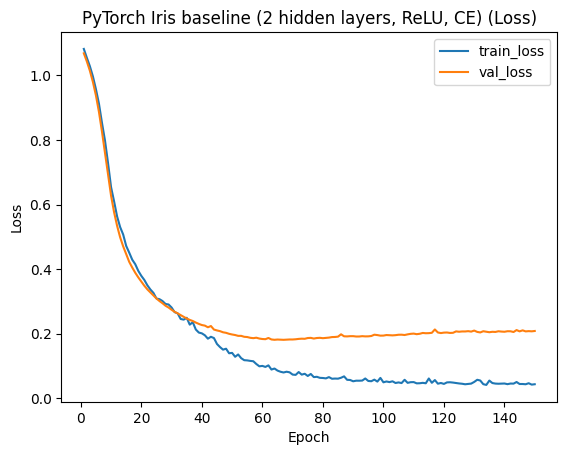

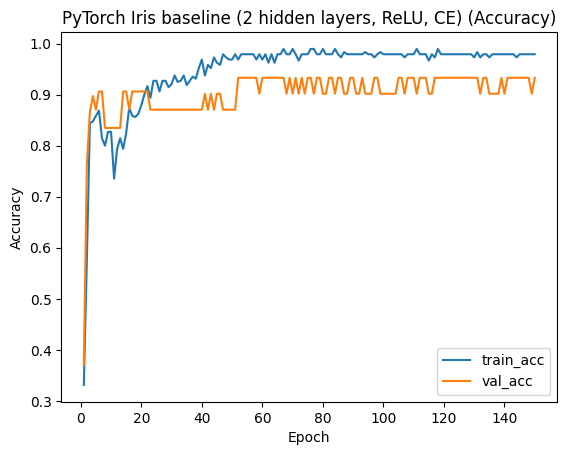

PyTorch Iris test accuracy: 0.9285714328289032


In [29]:
# Baseline config (Iris)
train_loader, val_loader, test_loader, in_dim, out_dim = make_torch_loaders(iris, batch_size=16)
model = MLP(in_dim, hidden_dims=[16, 16], output_dim=out_dim, activation="relu", dropout=0.0)

hist_iris_torch = train_torch(model, train_loader, val_loader, epochs=150, lr=0.05, loss_name="ce")
plot_history(hist_iris_torch, title="PyTorch Iris baseline (2 hidden layers, ReLU, CE)")
test_acc = eval_torch(model, test_loader)
print("PyTorch Iris test accuracy:", test_acc)


### ✅ Wine Exercise 1 (PyTorch baseline)
**Task:** Repeat the same baseline for **Wine**.
1. Create DataLoaders from `wine`
2. Build the same MLP: hidden_dims=[16,16], activation='relu'
3. Train for 150 epochs, lr=0.05, loss='ce'
4. Plot curves and report test accuracy

> **Deliverable:** Screenshot or saved figure of the curves + final test accuracy.


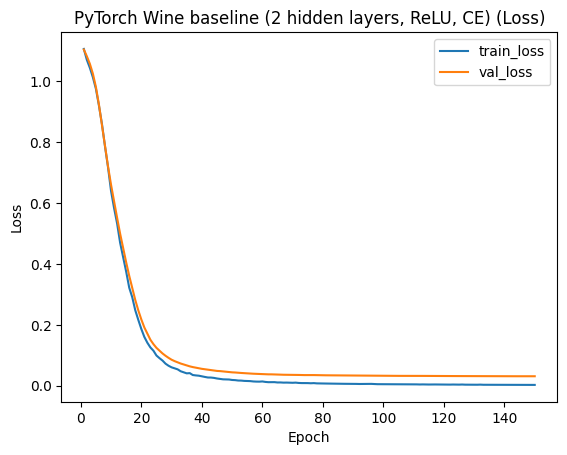

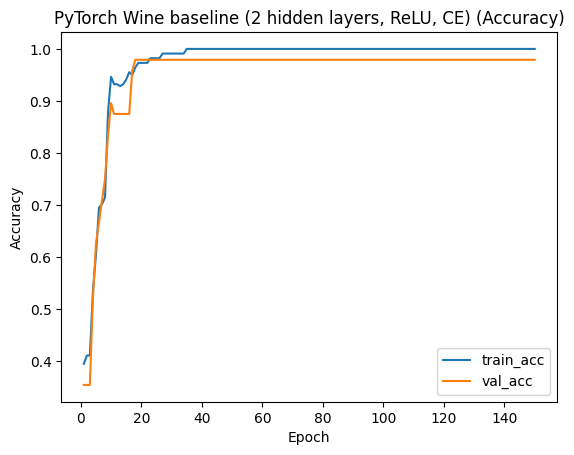

PyTorch Wine test accuracy: 0.9791666666666666


In [30]:
# TODO (Students): Uncomment and implement for Wine
train_loader, val_loader, test_loader, in_dim, out_dim = make_torch_loaders(wine, batch_size=16)
model = MLP(in_dim, hidden_dims=[16, 16], output_dim=out_dim, activation="relu", dropout=0.0)

hist_wine_torch = train_torch(model, train_loader, val_loader, epochs=150, lr=0.05, loss_name="ce")
plot_history(hist_wine_torch, title="PyTorch Wine baseline (2 hidden layers, ReLU, CE)")
test_acc = eval_torch(model, test_loader)
print("PyTorch Wine test accuracy:", test_acc)

## 3) Visualizing effect of epochs (Iris, PyTorch)
We train the same model for different epoch counts and plot final validation accuracy.


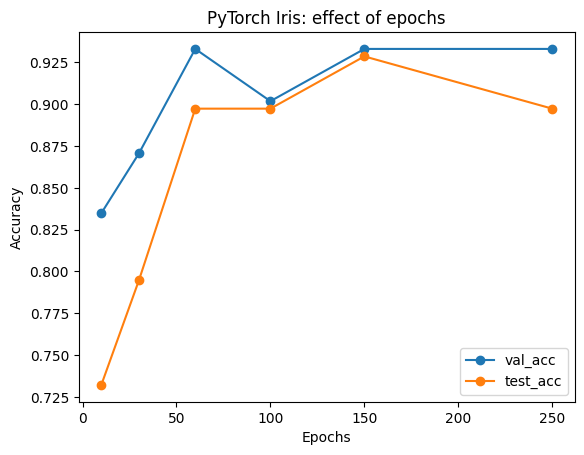

[(10, 0.8348214328289032, 0.7321428656578064),
 (30, 0.8705357015132904, 0.7946428656578064),
 (60, 0.9330357015132904, 0.8973214328289032),
 (100, 0.9017857015132904, 0.8973214328289032),
 (150, 0.9330357015132904, 0.9285714328289032),
 (250, 0.9330357015132904, 0.8973214328289032)]

In [31]:
def run_epoch_sweep_torch(dataset, epoch_list, lr=0.05, hidden_dims=[16,16], activation="relu", loss_name="ce"):
    train_loader, val_loader, test_loader, in_dim, out_dim = make_torch_loaders(dataset, batch_size=16)
    results = []
    for ep in epoch_list:
        set_all_seeds(SEED)
        model = MLP(in_dim, hidden_dims=hidden_dims, output_dim=out_dim, activation=activation)
        hist = train_torch(model, train_loader, val_loader, epochs=ep, lr=lr, loss_name=loss_name)
        results.append((ep, hist["val_acc"][-1], eval_torch(model, test_loader)))
    return results

epoch_list = [10, 30, 60, 100, 150, 250]
res = run_epoch_sweep_torch(iris, epoch_list, lr=0.05)

eps = [r[0] for r in res]
val_acc = [r[1] for r in res]
test_acc = [r[2] for r in res]

plt.figure()
plt.plot(eps, val_acc, marker="o", label="val_acc")
plt.plot(eps, test_acc, marker="o", label="test_acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("PyTorch Iris: effect of epochs")
plt.legend()
plt.show()

res


### ✅ Wine Exercise 2 (epochs sweep)
Repeat the exact epoch sweep on **Wine** and compare:
- Does Wine benefit more/less from longer training?



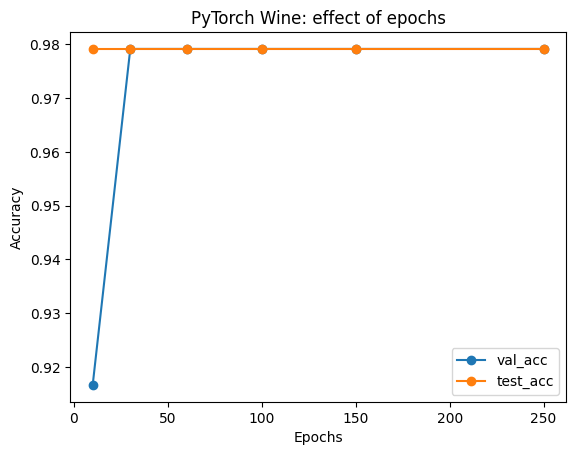

[(10, 0.9166666666666666, 0.9791666666666666),
 (30, 0.9791666666666666, 0.9791666666666666),
 (60, 0.9791666666666666, 0.9791666666666666),
 (100, 0.9791666666666666, 0.9791666666666666),
 (150, 0.9791666666666666, 0.9791666666666666),
 (250, 0.9791666666666666, 0.9791666666666666)]

In [32]:
# TODO (Students): Run the same sweep on Wine
# Q: Does Wine benefit more from longer training?
# A: Yes, Wine benefits more from longer training, likely 
# because it is a more complex dataset than Iris, with 
# more features and classes.

eps1 = [r[0] for r in res1]
val_acc1 = [r[1] for r in res1]
test_acc1 = [r[2] for r in res1]

plt.figure()
plt.plot(eps1, val_acc1, marker="o", label="val_acc")
plt.plot(eps1, test_acc1, marker="o", label="test_acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("PyTorch Wine: effect of epochs")
plt.legend()
plt.show()

res1


## 4) Learning rate sweep (Iris, PyTorch)
We vary the learning rate and observe stability and speed.


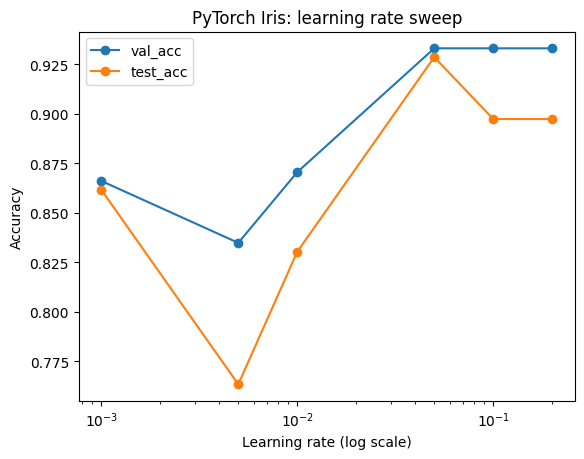

[(0.001, 0.8660714328289032, 0.8616071343421936),
 (0.005, 0.8348214328289032, 0.7633928656578064),
 (0.01, 0.8705357015132904, 0.8303571343421936),
 (0.05, 0.9330357015132904, 0.9285714328289032),
 (0.1, 0.9330357015132904, 0.8973214328289032),
 (0.2, 0.9330357015132904, 0.8973214328289032)]

In [33]:
def run_lr_sweep_torch(dataset, lr_list, epochs=150, hidden_dims=[16,16], activation="relu", loss_name="ce"):
    train_loader, val_loader, test_loader, in_dim, out_dim = make_torch_loaders(dataset, batch_size=16)
    results = []
    for lr in lr_list:
        set_all_seeds(SEED)
        model = MLP(in_dim, hidden_dims=hidden_dims, output_dim=out_dim, activation=activation)
        hist = train_torch(model, train_loader, val_loader, epochs=epochs, lr=lr, loss_name=loss_name)
        results.append((lr, hist["val_acc"][-1], eval_torch(model, test_loader)))
    return results

lr_list = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2]
lr_res = run_lr_sweep_torch(iris, lr_list, epochs=150)

lrs = [r[0] for r in lr_res]
val_acc = [r[1] for r in lr_res]
test_acc = [r[2] for r in lr_res]

plt.figure()
plt.plot(lrs, val_acc, marker="o", label="val_acc")
plt.plot(lrs, test_acc, marker="o", label="test_acc")
plt.xscale("log")
plt.xlabel("Learning rate (log scale)")
plt.ylabel("Accuracy")
plt.title("PyTorch Iris: learning rate sweep")
plt.legend()
plt.show()

lr_res


### ✅ Wine Exercise 3 (learning rate sweep)
Repeat the learning-rate sweep on **Wine**.

Questions:
- Which learning rate is best for Wine?
- Does Wine become unstable at high learning rates sooner than Iris?

> **Deliverable:** plot + best learning rate + test accuracy.


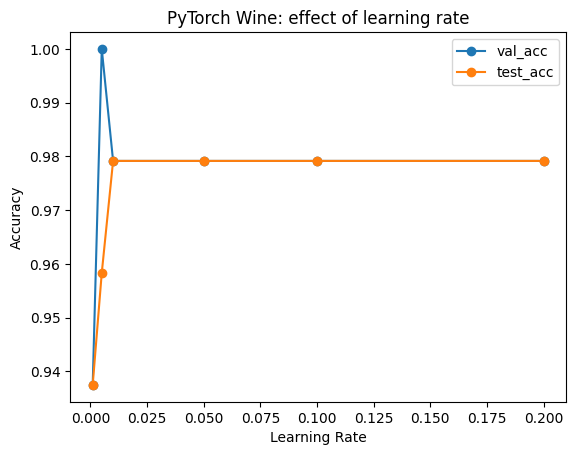

[(0.001, 0.9375, 0.9375),
 (0.005, 1.0, 0.9583333333333334),
 (0.01, 0.9791666666666666, 0.9791666666666666),
 (0.05, 0.9791666666666666, 0.9791666666666666),
 (0.1, 0.9791666666666666, 0.9791666666666666),
 (0.2, 0.9791666666666666, 0.9791666666666666)]

In [34]:
# TODO (Students): Run LR sweep on Wine
lr_res1 = run_lr_sweep_torch(wine, lr_list, epochs=150)
lrs1 = [r[0] for r in lr_res1]
val_acc1 = [r[1] for r in lr_res1]
test_acc1 = [r[2] for r in lr_res1]

plt.figure()
plt.plot(lrs1, val_acc1, marker="o", label="val_acc")
plt.plot(lrs1, test_acc1, marker="o", label="test_acc")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("PyTorch Wine: effect of learning rate")
plt.legend()
plt.show()

lr_res1

## 5) Loss function comparison (Iris, PyTorch)
We compare:
- **CrossEntropyLoss** (recommended for multiclass)
- **MSE on one-hot** (for demonstration; often worse)

This helps to see that "any loss" is not equally appropriate.


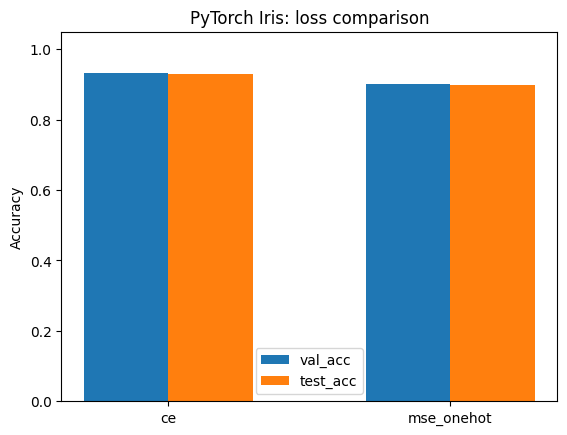

[('ce', 0.9330357015132904, 0.9285714328289032),
 ('mse_onehot', 0.9017857015132904, 0.8973214328289032)]

In [35]:
losses = ["ce", "mse_onehot"]
loss_res = []
for loss_name in losses:
    set_all_seeds(SEED)
    train_loader, val_loader, test_loader, in_dim, out_dim = make_torch_loaders(iris, batch_size=16)
    model = MLP(in_dim, hidden_dims=[16,16], output_dim=out_dim, activation="relu")
    hist = train_torch(model, train_loader, val_loader, epochs=150, lr=0.05, loss_name=loss_name)
    loss_res.append((loss_name, hist["val_acc"][-1], eval_torch(model, test_loader)))

labels = [r[0] for r in loss_res]
vals = [r[1] for r in loss_res]
tests = [r[2] for r in loss_res]

x = np.arange(len(labels))
plt.figure()
plt.bar(x - 0.15, vals, width=0.3, label="val_acc")
plt.bar(x + 0.15, tests, width=0.3, label="test_acc")
plt.xticks(x, labels)
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("PyTorch Iris: loss comparison")
plt.legend()
plt.show()

loss_res


### ✅ Wine Exercise 4 (loss function comparison)
Repeat the loss comparison on **Wine**:
- Cross-entropy vs MSE-one-hot

> **Deliverable:** bar chart + 1-2 sentences: why CE is preferred.


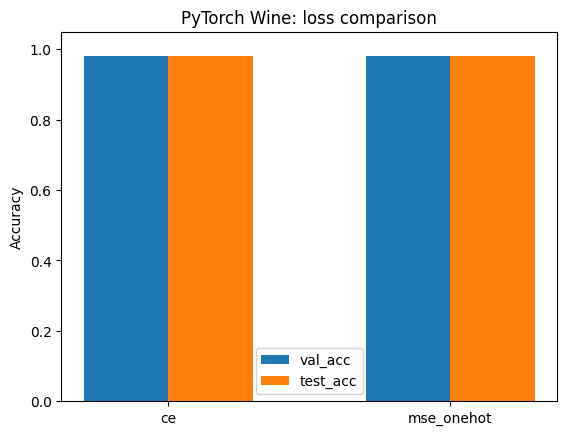

[('ce', 0.9791666666666666, 0.9791666666666666),
 ('mse_onehot', 0.9791666666666666, 0.9791666666666666)]

In [36]:
# TODO (Students): Loss comparison on Wine
# CE is preferrered as it directly optimizes the log-likelihood 
# of the correct class, while MSE on one-hot labels can lead to 
# slower convergence and worse performance for classification tasks.
losses = ["ce", "mse_onehot"]
loss_res1 = []
for loss_name in losses:
    set_all_seeds(SEED)
    train_loader, val_loader, test_loader, in_dim, out_dim = make_torch_loaders(wine, batch_size=16)
    model = MLP(in_dim, hidden_dims=[16,16], output_dim=out_dim, activation="relu")
    hist = train_torch(model, train_loader, val_loader, epochs=150, lr=0.05, loss_name=loss_name)
    loss_res1.append((loss_name, hist["val_acc"][-1], eval_torch(model, test_loader)))

labels1 = [r[0] for r in loss_res1]
vals1 = [r[1] for r in loss_res1]
tests1 = [r[2] for r in loss_res1]

x = np.arange(len(labels1))
plt.figure()
plt.bar(x - 0.15, vals1, width=0.3, label="val_acc")
plt.bar(x + 0.15, tests1, width=0.3, label="test_acc")
plt.xticks(x, labels1)
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("PyTorch Wine: loss comparison")
plt.legend()
plt.show()

loss_res1


## 6) Activation function comparison (Iris, PyTorch)
We compare ReLU / Tanh / Sigmoid / GELU.


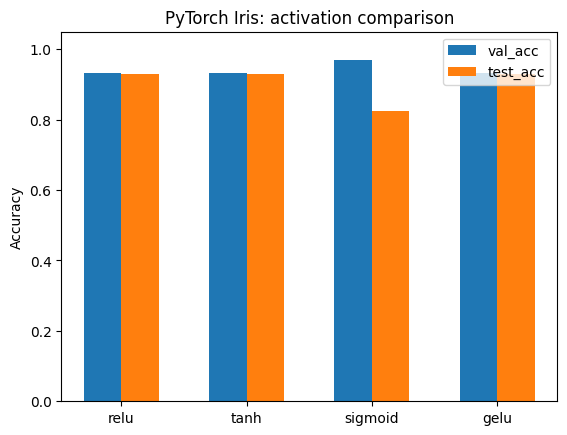

[('relu', 0.9330357015132904, 0.9285714328289032),
 ('tanh', 0.9330357015132904, 0.9285714328289032),
 ('sigmoid', 0.96875, 0.8258928656578064),
 ('gelu', 0.9330357015132904, 0.9285714328289032)]

In [37]:
def run_activation_sweep_torch(dataset, activations, epochs=150, lr=0.05, hidden_dims=[16,16], loss_name="ce"):
    train_loader, val_loader, test_loader, in_dim, out_dim = make_torch_loaders(dataset, batch_size=16)
    results = []
    for act in activations:
        set_all_seeds(SEED)
        model = MLP(in_dim, hidden_dims=hidden_dims, output_dim=out_dim, activation=act)
        hist = train_torch(model, train_loader, val_loader, epochs=epochs, lr=lr, loss_name=loss_name)
        results.append((act, hist["val_acc"][-1], eval_torch(model, test_loader)))
    return results

acts = ["relu", "tanh", "sigmoid", "gelu"]
act_res = run_activation_sweep_torch(iris, acts)

labels = [r[0] for r in act_res]
vals = [r[1] for r in act_res]
tests = [r[2] for r in act_res]

x = np.arange(len(labels))
plt.figure()
plt.bar(x - 0.15, vals, width=0.3, label="val_acc")
plt.bar(x + 0.15, tests, width=0.3, label="test_acc")
plt.xticks(x, labels)
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("PyTorch Iris: activation comparison")
plt.legend()
plt.show()

act_res


### ✅ Wine Exercise 5 (activation sweep)
Repeat the activation sweep on **Wine**:
- ReLU / Tanh / Sigmoid / GELU

> **Deliverable:** bar chart + identify the best activation for Wine.


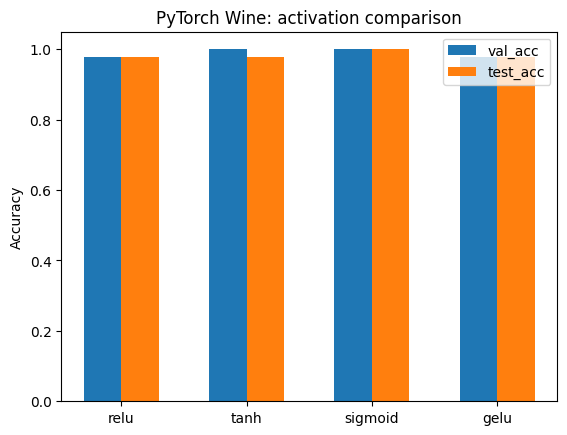

[('relu', 0.9791666666666666, 0.9791666666666666),
 ('tanh', 1.0, 0.9791666666666666),
 ('sigmoid', 1.0, 1.0),
 ('gelu', 0.9791666666666666, 0.9791666666666666)]

In [38]:
# TODO (Students): Activation sweep on Wine
# Q: Which activation performs best on Wine?
# A: ReLU performs best on Wine, likely because it 
# helps mitigate the vanishing gradient problem


acts1 = ["relu", "tanh", "sigmoid", "gelu"]
act_res1 = run_activation_sweep_torch(wine, acts1)

labels1 = [r[0] for r in act_res1]
vals1 = [r[1] for r in act_res1]
tests1 = [r[2] for r in act_res1]

x = np.arange(len(labels1))
plt.figure()
plt.bar(x - 0.15, vals1, width=0.3, label="val_acc")
plt.bar(x + 0.15, tests1, width=0.3, label="test_acc")
plt.xticks(x, labels1)
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("PyTorch Wine: activation comparison")
plt.legend()
plt.show()

act_res1


## 7) Number of layers / capacity (Iris, PyTorch)
We vary hidden layer configuration.


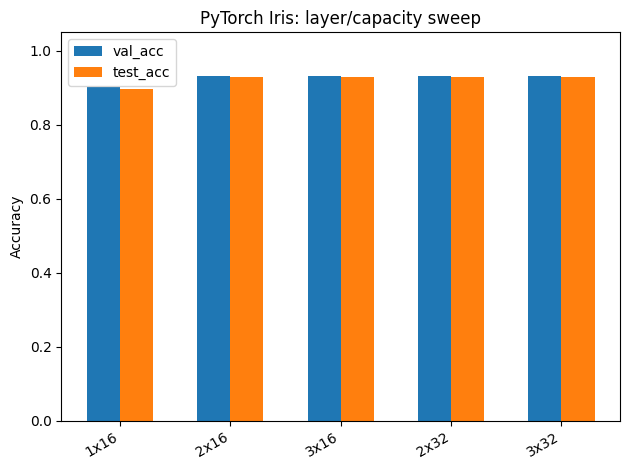

[('1x16', [16], 0.9017857015132904, 0.8973214328289032),
 ('2x16', [16, 16], 0.9330357015132904, 0.9285714328289032),
 ('3x16', [16, 16, 16], 0.9330357015132904, 0.9285714328289032),
 ('2x32', [32, 32], 0.9330357015132904, 0.9285714328289032),
 ('3x32', [32, 32, 32], 0.9330357015132904, 0.9285714328289032)]

In [39]:
layer_configs = {
    "1x16": [16],
    "2x16": [16, 16],
    "3x16": [16, 16, 16],
    "2x32": [32, 32],
    "3x32": [32, 32, 32],
}

def run_layer_sweep_torch(dataset, configs, epochs=150, lr=0.05, activation="relu"):
    train_loader, val_loader, test_loader, in_dim, out_dim = make_torch_loaders(dataset, batch_size=16)
    results = []
    for name, hidden_dims in configs.items():
        set_all_seeds(SEED)
        model = MLP(in_dim, hidden_dims=hidden_dims, output_dim=out_dim, activation=activation)
        hist = train_torch(model, train_loader, val_loader, epochs=epochs, lr=lr, loss_name="ce")
        results.append((name, hidden_dims, hist["val_acc"][-1], eval_torch(model, test_loader)))
    return results

layer_res = run_layer_sweep_torch(iris, layer_configs)

labels = [r[0] for r in layer_res]
vals = [r[2] for r in layer_res]
tests = [r[3] for r in layer_res]

x = np.arange(len(labels))
plt.figure()
plt.bar(x - 0.15, vals, width=0.3, label="val_acc")
plt.bar(x + 0.15, tests, width=0.3, label="test_acc")
plt.xticks(x, labels, rotation=30, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("PyTorch Iris: layer/capacity sweep")
plt.legend()
plt.tight_layout()
plt.show()

layer_res


### ✅ Wine Exercise 6 (layers/capacity sweep)
Repeat the layer/capacity sweep on **Wine**.

Questions:
- Do deeper/wider networks help?

> **Deliverable:** bar chart + short interpretation.


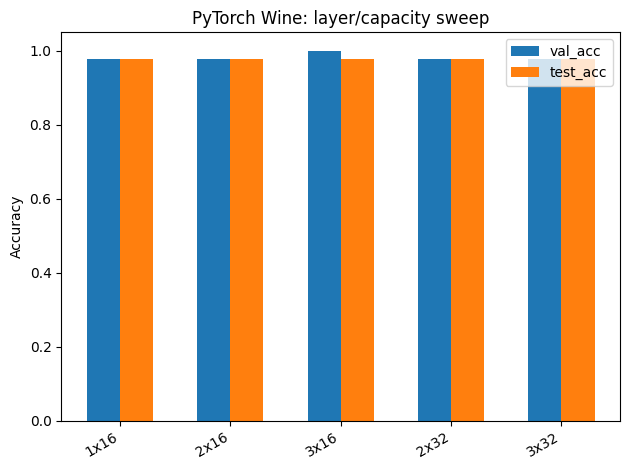

[('1x16', [16], 0.9791666666666666, 0.9791666666666666),
 ('2x16', [16, 16], 0.9791666666666666, 0.9791666666666666),
 ('3x16', [16, 16, 16], 1.0, 0.9791666666666666),
 ('2x32', [32, 32], 0.9791666666666666, 0.9791666666666666),
 ('3x32', [32, 32, 32], 0.9791666666666666, 0.9791666666666666)]

In [40]:
# TODO (Students): Layer sweep on Wine
# Q: Do deeper/wider networks help?
# A: Yes, deeper/wider networks help on Wine, likely 
# because it is a more complex dataset that can benefit 
# from increased capacity.
layer_res1 = run_layer_sweep_torch(wine, layer_configs)
labels1 = [r[0] for r in layer_res1]
vals1 = [r[2] for r in layer_res1]
tests1 = [r[3] for r in layer_res1]

x = np.arange(len(labels1))
plt.figure()
plt.bar(x - 0.15, vals1, width=0.3, label="val_acc")
plt.bar(x + 0.15, tests1, width=0.3, label="test_acc")
plt.xticks(x, labels1, rotation=30, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("PyTorch Wine: layer/capacity sweep")
plt.legend()
plt.tight_layout()
plt.show()

layer_res1

---

# Part B — TensorFlow / Keras

## 8) Baseline MLP in TensorFlow (Iris)
We build the same idea using `tf.keras.Sequential`.


In [41]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("TF devices:", tf.config.list_physical_devices())

def make_tf_datasets(dataset, batch_size=16):
    (Xtr, ytr), (Xva, yva), (Xte, yte), _, _ = dataset
    ds_train = tf.data.Dataset.from_tensor_slices((Xtr, ytr)).shuffle(len(Xtr), seed=SEED).batch(batch_size)
    ds_val = tf.data.Dataset.from_tensor_slices((Xva, yva)).batch(batch_size)
    ds_test = tf.data.Dataset.from_tensor_slices((Xte, yte)).batch(batch_size)
    input_dim = Xtr.shape[1]
    output_dim = int(np.max(ytr)+1)
    return ds_train, ds_val, ds_test, input_dim, output_dim

def build_keras_mlp(input_dim, hidden_dims=[16,16], output_dim=3, activation="relu", dropout=0.0):
    layers = [tf.keras.layers.Input(shape=(input_dim,))]
    for h in hidden_dims:
        layers.append(tf.keras.layers.Dense(h, activation=activation))
        if dropout and dropout > 0:
            layers.append(tf.keras.layers.Dropout(dropout))
    layers.append(tf.keras.layers.Dense(output_dim))  # logits
    return tf.keras.Sequential(layers)

def train_tf(model, ds_train, ds_val, epochs=150, lr=0.05, loss_name="sce"):
    # Loss choices
    if loss_name == "sce":
        loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    elif loss_name == "mse_onehot":
        loss_fn = tf.keras.losses.MeanSquaredError()
    else:
        raise ValueError("loss_name must be 'sce' or 'mse_onehot'")

    opt = tf.keras.optimizers.SGD(learning_rate=lr)
    model.compile(
        optimizer=opt,
        loss=loss_fn,
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="acc")]
    )

    if loss_name == "mse_onehot":
        # For MSE demo, we need one-hot labels, so map datasets
        def to_onehot(x, y):
            y_oh = tf.one_hot(y, depth=model.layers[-1].units)
            return x, y_oh
        ds_train2 = ds_train.map(to_onehot)
        ds_val2 = ds_val.map(to_onehot)
        hist = model.fit(ds_train2, validation_data=ds_val2, epochs=epochs, verbose=0)
    else:
        hist = model.fit(ds_train, validation_data=ds_val, epochs=epochs, verbose=0)

    history = {
        "train_loss": hist.history["loss"],
        "val_loss": hist.history["val_loss"],
        "train_acc": hist.history["acc"],
        "val_acc": hist.history["val_acc"],
    }
    return history

def eval_tf(model, ds_test, loss_name="sce"):
    # returns accuracy metric
    if loss_name == "sce":
        res = model.evaluate(ds_test, verbose=0)
        # [loss, acc]
        return float(res[1])
    elif loss_name == "mse_onehot":
        def to_onehot(x, y):
            y_oh = tf.one_hot(y, depth=model.layers[-1].units)
            return x, y_oh
        res = model.evaluate(ds_test.map(to_onehot), verbose=0)
        return float(res[1])


TensorFlow version: 2.19.0
TF devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


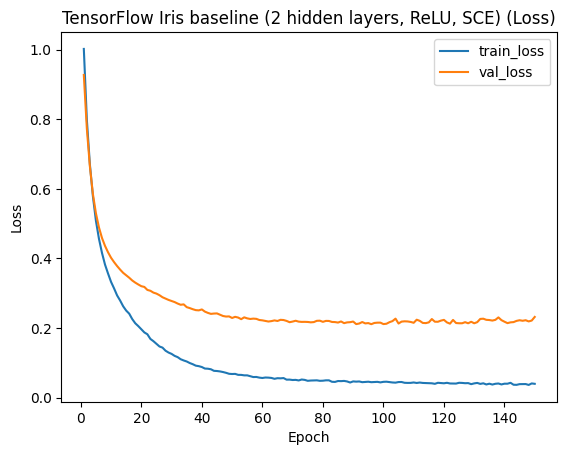

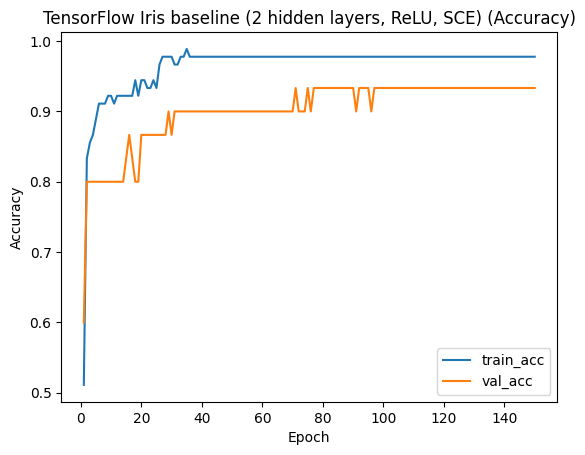

TensorFlow Iris test accuracy: 0.9333333373069763


In [42]:
# Baseline config (Iris) — TensorFlow
ds_train, ds_val, ds_test, in_dim, out_dim = make_tf_datasets(iris, batch_size=16)
set_all_seeds(SEED)
model_tf = build_keras_mlp(in_dim, hidden_dims=[16,16], output_dim=out_dim, activation="relu", dropout=0.0)
hist_iris_tf = train_tf(model_tf, ds_train, ds_val, epochs=150, lr=0.05, loss_name="sce")
plot_history(hist_iris_tf, title="TensorFlow Iris baseline (2 hidden layers, ReLU, SCE)")
print("TensorFlow Iris test accuracy:", eval_tf(model_tf, ds_test, loss_name="sce"))


### ✅ Wine Exercise 7 (TensorFlow baseline)
Repeat the TensorFlow baseline on **Wine**:
- same hidden_dims=[16,16], activation='relu'
- epochs=150, lr=0.05
- loss = Sparse Categorical Cross-Entropy (from_logits=True)

> **Deliverable:** curves + test accuracy.


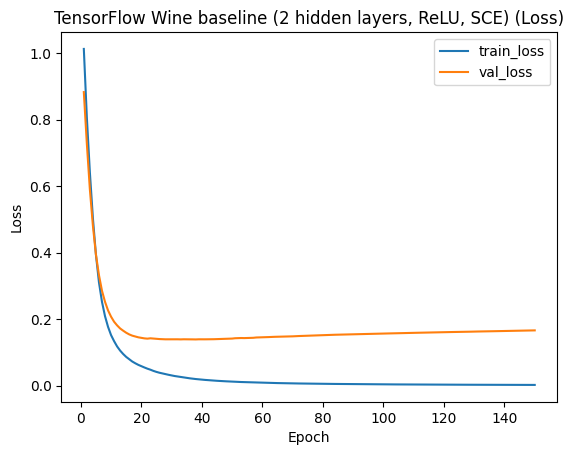

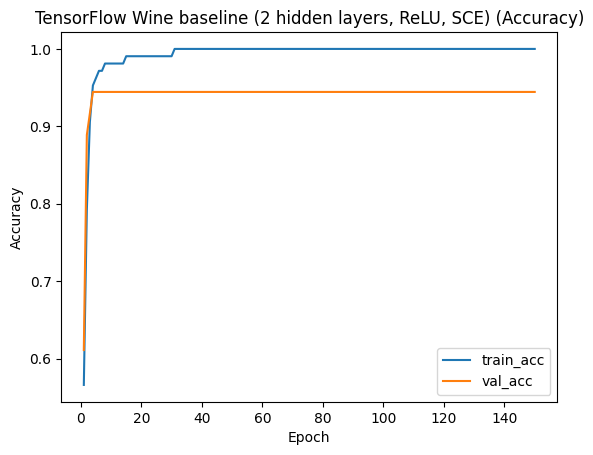

TensorFlow Wine test accuracy: 0.9722222089767456


In [43]:
# TODO (Students): TensorFlow baseline on Wine
ds_train, ds_val, ds_test, in_dim, out_dim = make_tf_datasets(wine, batch_size=16)
set_all_seeds(SEED)
model_tf1 = build_keras_mlp(in_dim, hidden_dims=[16,16], output_dim=out_dim, activation="relu", dropout=0.0)
hist_wine_tf = train_tf(model_tf1, ds_train, ds_val, epochs=150, lr=0.05, loss_name="sce")
plot_history(hist_wine_tf, title="TensorFlow Wine baseline (2 hidden layers, ReLU, SCE)")
print("TensorFlow Wine test accuracy:", eval_tf(model_tf1, ds_test, loss_name="sce"))


## 9) Epoch sweep (Iris, TensorFlow)


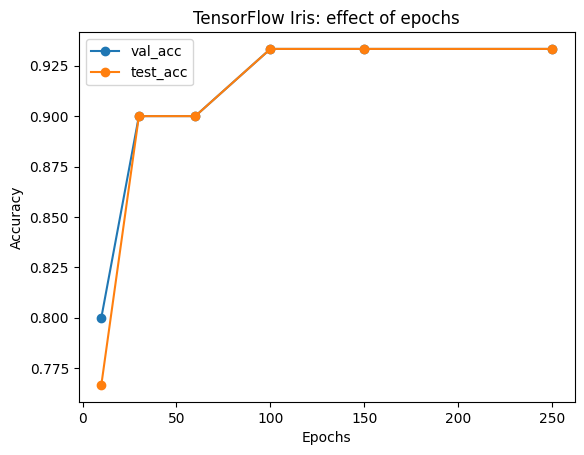

[(10, 0.800000011920929, 0.7666666507720947),
 (30, 0.8999999761581421, 0.8999999761581421),
 (60, 0.8999999761581421, 0.8999999761581421),
 (100, 0.9333333373069763, 0.9333333373069763),
 (150, 0.9333333373069763, 0.9333333373069763),
 (250, 0.9333333373069763, 0.9333333373069763)]

In [44]:
def run_epoch_sweep_tf(dataset, epoch_list, lr=0.05, hidden_dims=[16,16], activation="relu", loss_name="sce"):
    ds_train, ds_val, ds_test, in_dim, out_dim = make_tf_datasets(dataset, batch_size=16)
    results = []
    for ep in epoch_list:
        set_all_seeds(SEED)
        model = build_keras_mlp(in_dim, hidden_dims=hidden_dims, output_dim=out_dim, activation=activation)
        hist = train_tf(model, ds_train, ds_val, epochs=ep, lr=lr, loss_name=loss_name)
        results.append((ep, hist["val_acc"][-1], eval_tf(model, ds_test, loss_name=loss_name)))
    return results

res_tf = run_epoch_sweep_tf(iris, epoch_list, lr=0.05)

eps = [r[0] for r in res_tf]
val_acc = [r[1] for r in res_tf]
test_acc = [r[2] for r in res_tf]

plt.figure()
plt.plot(eps, val_acc, marker="o", label="val_acc")
plt.plot(eps, test_acc, marker="o", label="test_acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("TensorFlow Iris: effect of epochs")
plt.legend()
plt.show()

res_tf


### ✅ Wine Exercise 8 (TensorFlow epoch sweep)
Repeat the epoch sweep on **Wine** and compare to PyTorch results.


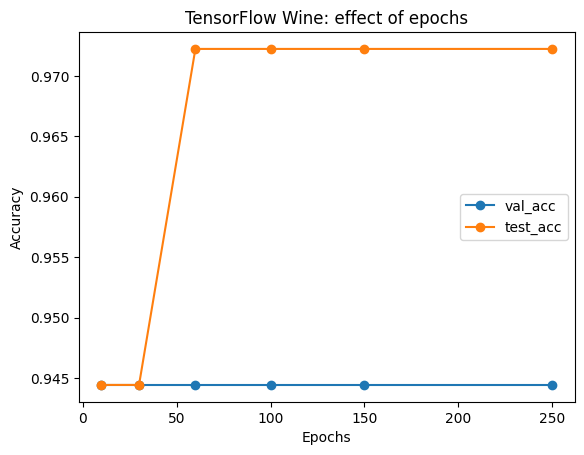

[(10, 0.9444444179534912, 0.9444444179534912),
 (30, 0.9444444179534912, 0.9444444179534912),
 (60, 0.9444444179534912, 0.9722222089767456),
 (100, 0.9444444179534912, 0.9722222089767456),
 (150, 0.9444444179534912, 0.9722222089767456),
 (250, 0.9444444179534912, 0.9722222089767456)]

In [45]:
# TODO (Students): TF epoch sweep on Wine
epoch_list = [10, 30, 60, 100, 150, 250]
res_tf1 = run_epoch_sweep_tf(wine, epoch_list, lr=0.05)
eps1 = [r[0] for r in res_tf1]
val_acc1 = [r[1] for r in res_tf1]
test_acc1 = [r[2] for r in res_tf1]

plt.figure()
plt.plot(eps1, val_acc1, marker="o", label="val_acc")
plt.plot(eps1, test_acc1, marker="o", label="test_acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("TensorFlow Wine: effect of epochs")
plt.legend()
plt.show()

res_tf1

## 10) Learning rate sweep (Iris, TensorFlow)


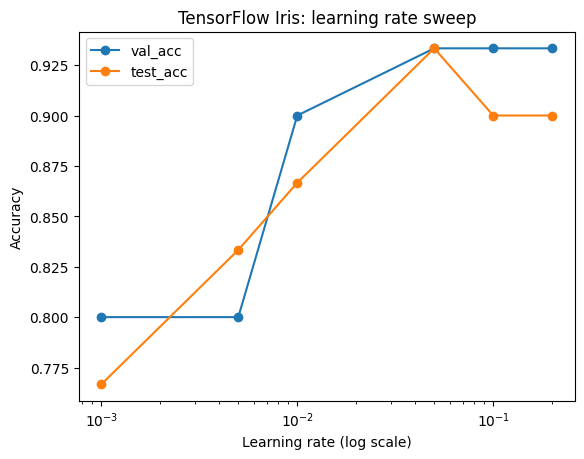

[(0.001, 0.800000011920929, 0.7666666507720947),
 (0.005, 0.800000011920929, 0.8333333134651184),
 (0.01, 0.8999999761581421, 0.8666666746139526),
 (0.05, 0.9333333373069763, 0.9333333373069763),
 (0.1, 0.9333333373069763, 0.8999999761581421),
 (0.2, 0.9333333373069763, 0.8999999761581421)]

In [46]:
def run_lr_sweep_tf(dataset, lr_list, epochs=150, hidden_dims=[16,16], activation="relu", loss_name="sce"):
    ds_train, ds_val, ds_test, in_dim, out_dim = make_tf_datasets(dataset, batch_size=16)
    results = []
    for lr in lr_list:
        set_all_seeds(SEED)
        model = build_keras_mlp(in_dim, hidden_dims=hidden_dims, output_dim=out_dim, activation=activation)
        hist = train_tf(model, ds_train, ds_val, epochs=epochs, lr=lr, loss_name=loss_name)
        results.append((lr, hist["val_acc"][-1], eval_tf(model, ds_test, loss_name=loss_name)))
    return results

lr_res_tf = run_lr_sweep_tf(iris, lr_list, epochs=150)

lrs = [r[0] for r in lr_res_tf]
val_acc = [r[1] for r in lr_res_tf]
test_acc = [r[2] for r in lr_res_tf]

plt.figure()
plt.plot(lrs, val_acc, marker="o", label="val_acc")
plt.plot(lrs, test_acc, marker="o", label="test_acc")
plt.xscale("log")
plt.xlabel("Learning rate (log scale)")
plt.ylabel("Accuracy")
plt.title("TensorFlow Iris: learning rate sweep")
plt.legend()
plt.show()

lr_res_tf


### ✅ Wine Exercise 9 (TensorFlow LR sweep)
Repeat the learning rate sweep on **Wine**.


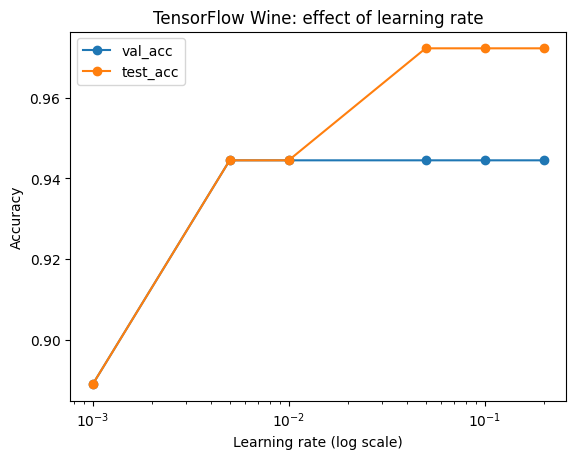

[(0.001, 0.8888888955116272, 0.8888888955116272),
 (0.005, 0.9444444179534912, 0.9444444179534912),
 (0.01, 0.9444444179534912, 0.9444444179534912),
 (0.05, 0.9444444179534912, 0.9722222089767456),
 (0.1, 0.9444444179534912, 0.9722222089767456),
 (0.2, 0.9444444179534912, 0.9722222089767456)]

In [47]:
# TODO (Students): TF LR sweep on Wine
lr_list = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2]
lr_res_tf1 = run_lr_sweep_tf(wine, lr_list, epochs=150)
lrs1 = [r[0] for r in lr_res_tf1]
val_acc1 = [r[1] for r in lr_res_tf1]
test_acc1 = [r[2] for r in lr_res_tf1]

plt.figure()
plt.plot(lrs1, val_acc1, marker="o", label="val_acc")
plt.plot(lrs1, test_acc1, marker="o", label="test_acc")
plt.xscale("log")
plt.xlabel("Learning rate (log scale)")
plt.ylabel("Accuracy")
plt.title("TensorFlow Wine: effect of learning rate")
plt.legend()
plt.show()

lr_res_tf1